# Combined Experiment Visualization: COMPARISON-PROMPTS + ABLATION-PROMPTS-CROSSOVER

Visualization of results from two combined experiments.

**Experiment 1 â€” COMPARISON-PROMPTS** (3 seeds each):
- **GA-LLAMEA-InitPrompt** â€” GA-LLAMEA with initialization prompt variant
- **GA-LLAMEA-OriginalPrompt** â€” GA-LLAMEA with original prompt

**Experiment 2 â€” ABLATION-PROMPTS-CROSSOVER** (5 seeds each):
- **Baseline-LLaMEA** â€” Standard LLaMEA baseline
- **LLaMEA-Crossover1-NoRefine** â€” LLaMEA with single-parent crossover, no refinement
- **LLaMEA-Crossover3-NoRefine** â€” LLaMEA with three-parent crossover, no refinement

**Problem:** MA_BBOB (dims=[5], budget_factor=2000, LLM budget=100)

**Sections:**
1. Setup and Data Loading
2. Convergence Plots
3. CEG (Code Evolution Graphs)
4. GA-LLAMEA Arm Selection Percentages
5. Boxplots (Fitness Comparison)
6. Fitness Table (Statistical Summary)
7. EAF / ECDF Diagrams
8. Elo Rating (Tournament Ranking)
9. Summary and Comparison

## 1. Setup and Data Loading

In [22]:
# Core imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# BLADE imports
from iohblade.loggers import ExperimentLogger
from iohblade.plots import (
    plot_convergence,
    plot_experiment_CEG,
    plot_boxplot_fitness_hue,
    plot_boxplot_fitness,
    fitness_table,
)
from iohblade.behaviour_metrics import compute_behavior_metrics

# Optional imports for code projection
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Plot styling
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_palette('colorblind')

print('All imports successful.')

All imports successful.


In [23]:
# Experiment directories to combine
# Add the ABLATION-WARMUP-LARGEPOP directory below once the experiment completes.
# Replace the placeholder timestamp with the actual one from the results folder.
EXPERIMENT_DIRS = [
    '../results/GA-LLAMEA-8-INIT-100',
    '../results/CROSSOVER-ABLATION',
    '../results/EoH',
]


# Load the first experiment as the primary logger, then add the second
logger = ExperimentLogger(EXPERIMENT_DIRS[0], True)
for extra_dir in EXPERIMENT_DIRS[1:]:
    logger.add_read_dir(extra_dir)

# Get available methods and problems
methods, problems = logger.get_methods_problems()
print(f'Methods ({len(methods)}): {sorted(methods)}')
print(f'Problems ({len(problems)}): {problems}')

Methods (5): ['Baseline-LLaMEA', 'EoH', 'GA-LLAMEA-8-INIT-100', 'LLaMEA-Crossover1-NoRefine', 'LLaMEA-Crossover3-NoRefine']
Problems (1): ['MA_BBOB']


In [24]:
# Experiment directories to combine
# Add the ABLATION-WARMUP-LARGEPOP directory below once the experiment completes.
# Replace the placeholder timestamp with the actual one from the results folder.
EXPERIMENT_DIRS = [
    '../results/EoH',
    '../results/CROSSOVER-ABLATION/baseline-LLAMEA',
    '../results/GA-LLAMEA-8-INIT-100'
]

# Load the first experiment as the primary logger, then add the second
logger = ExperimentLogger(EXPERIMENT_DIRS[0], True)
for extra_dir in EXPERIMENT_DIRS[1:]:
    logger.add_read_dir(extra_dir)

# Get available methods and problems
methods, problems = logger.get_methods_problems()
print(f'Methods ({len(methods)}): {sorted(methods)}')
print(f'Problems ({len(problems)}): {problems}')

Methods (3): ['Baseline-LLaMEA', 'EoH', 'GA-LLAMEA-8-INIT-100']
Problems (1): ['MA_BBOB']


In [25]:
# get_data() now handles empty/unreadable experimentlog.jsonl files gracefully.
# No manual dir filtering needed.

## 2. Convergence Plots

Comparing the convergence of methods across the LLM evaluation budget.

AOCC Convergence Plot


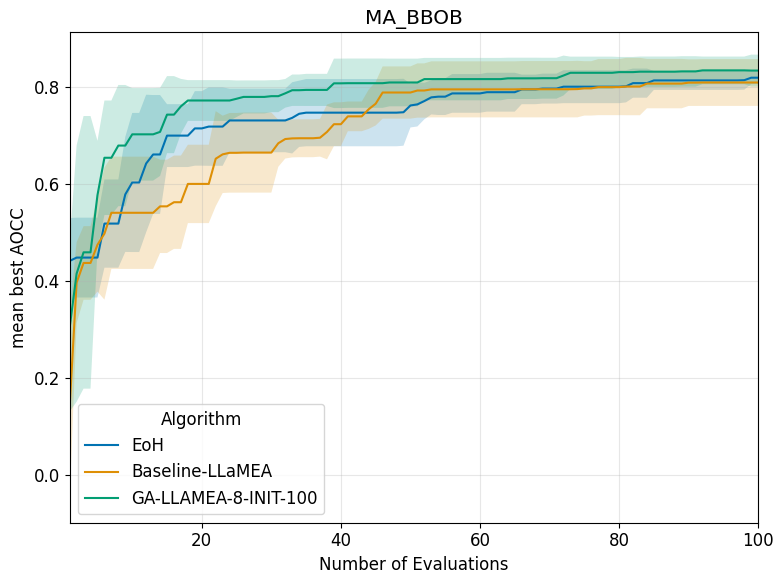

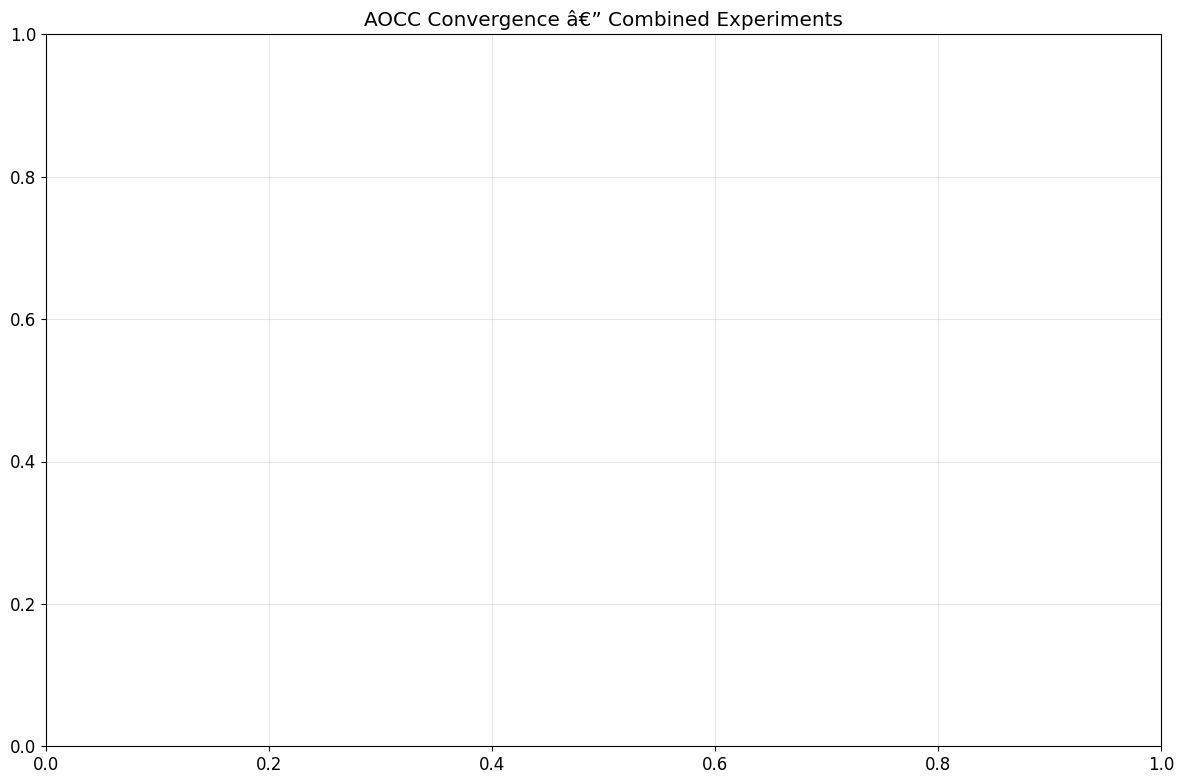

In [26]:
# AOCC Convergence (Area Over the Convergence Curve)
print('AOCC Convergence Plot')
try:
    plot_convergence(logger, metric='AOCC', save=False, budget=100)
    plt.title('AOCC Convergence â€” Combined Experiments')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error plotting AOCC convergence: {e}')

Fitness Convergence Plot


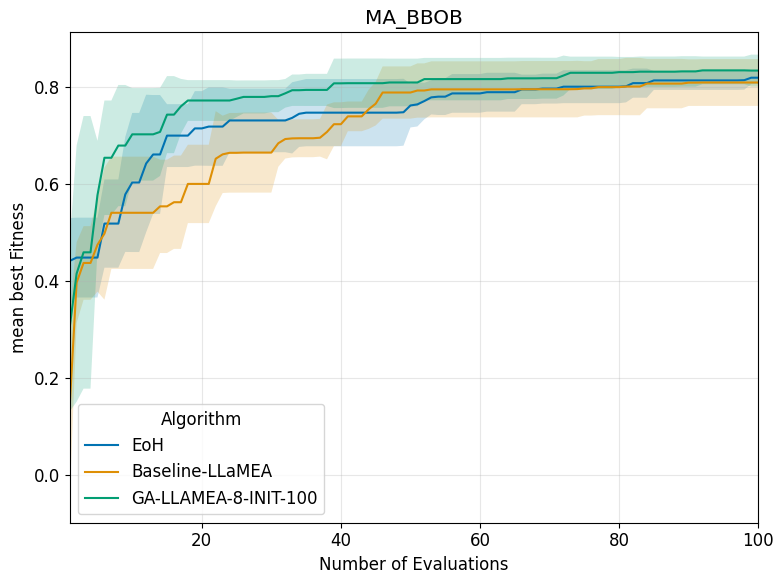

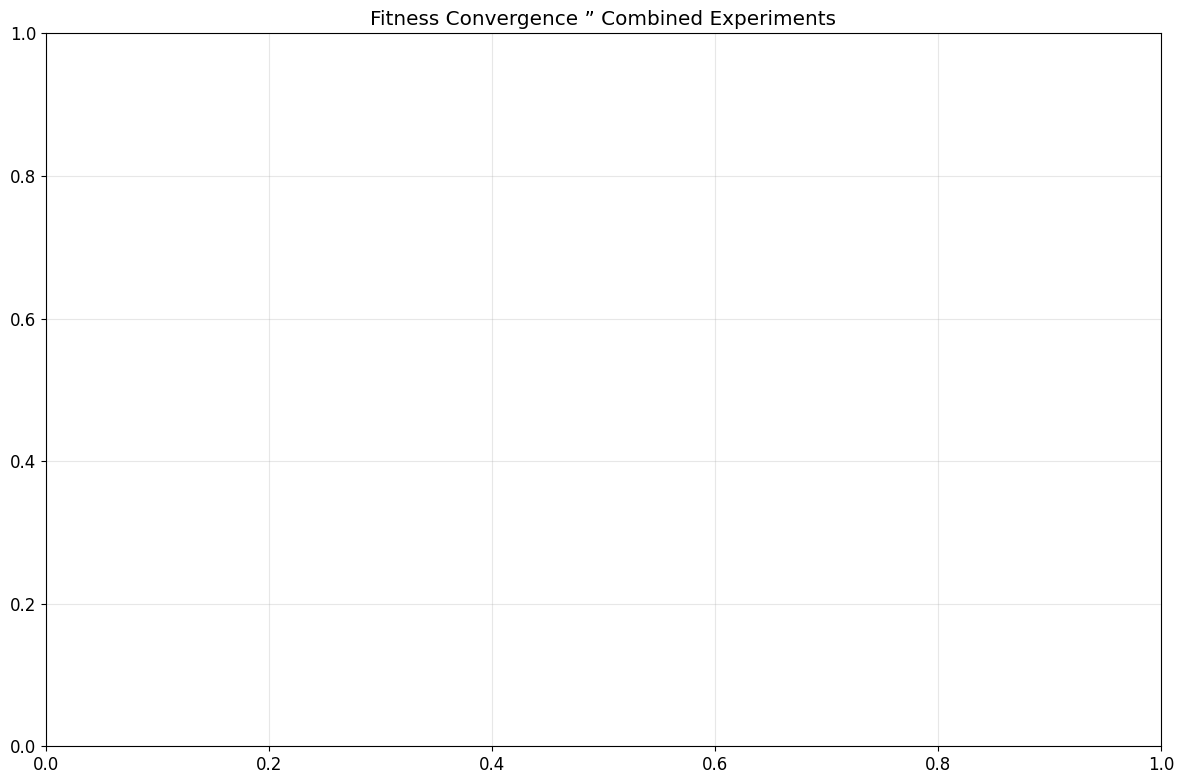

In [27]:
# Fitness Convergence
print('Fitness Convergence Plot')
try:
    plot_convergence(logger, metric='Fitness', save=False, budget=100)
    plt.title('Fitness Convergence ” Combined Experiments')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error plotting Fitness convergence: {e}')

## 3. CEG (Code Evolution Graphs)

Visualize how code complexity and quality evolve over the optimization budget for each run.

Code Evolution Graphs


c:\Users\Kukoy\Documents\Experiment-GA\WORKING-GA-LLAMEA\venv\Lib\site-packages\iohblade\plots.py:385: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace([np.inf, -np.inf], np.nan, inplace=True)
c:\Users\Kukoy\Documents\Experiment-GA\WORKING-GA-LLAMEA\venv\Lib\site-packages\iohblade\plots.py:385: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace([np.inf, -np.inf], np.nan, inplace=True)
c:\Users\Kukoy\Documents\Experiment-GA\WORKING-GA-LLAMEA\venv\Lib\site-packages\iohblade\plots.py:385: FutureWarning: Downcasting 

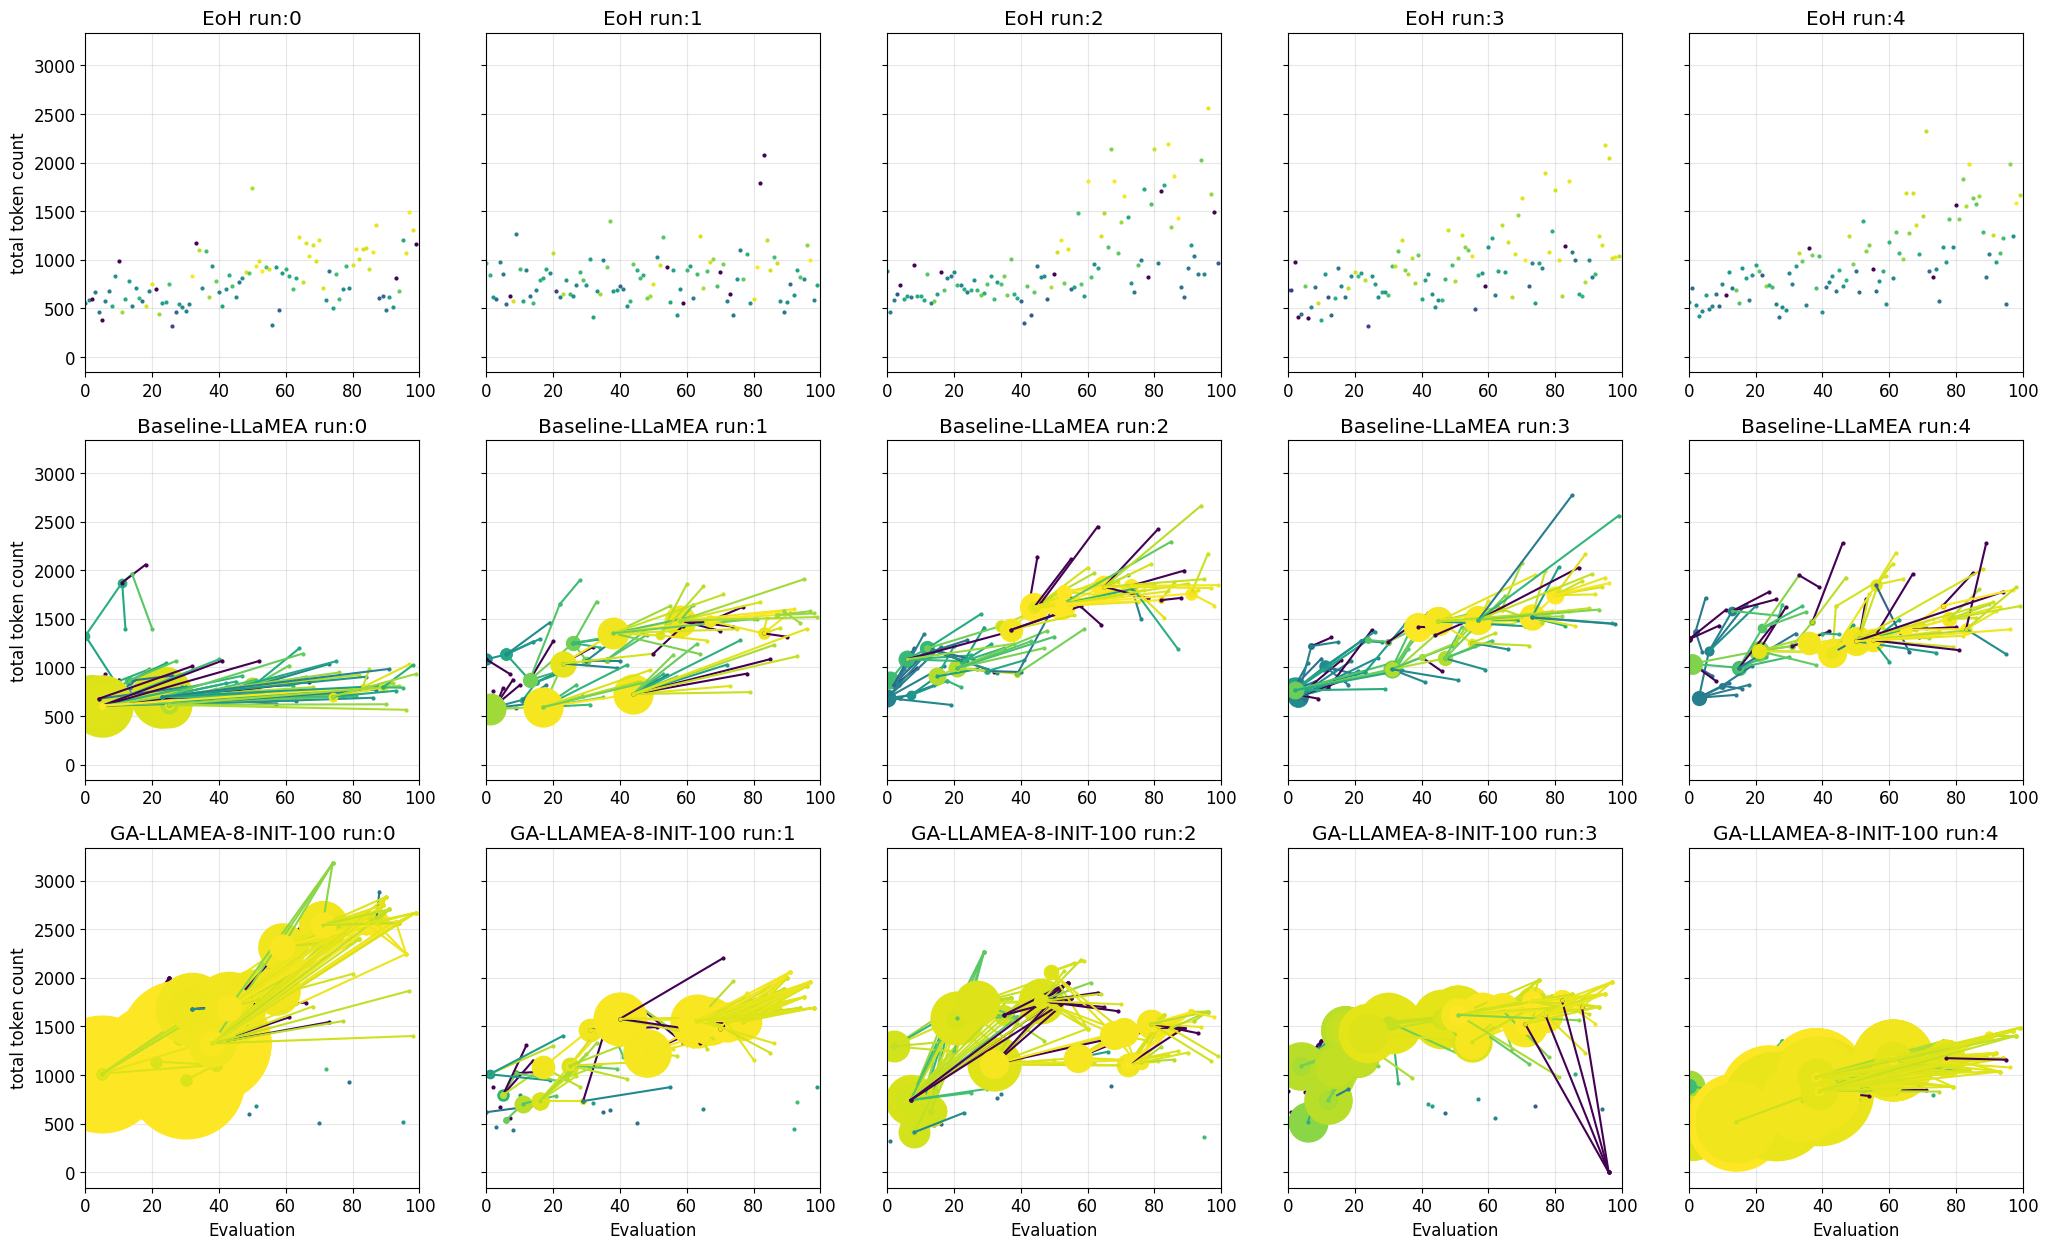

In [28]:
print('Code Evolution Graphs')
try:
    plot_experiment_CEG(logger, save=False, budget=100, max_seeds=5)
    plt.show()
except Exception as e:
    print(f'Error plotting CEG: {e}')

## 4. GA-LLAMEA Arm Selection Percentages

Visualize how the D-TS bandit distributes operator selections (mutation, crossover, random_new) over the course of each GA-LLAMEA run. This shows whether the bandit learns to prefer certain operators over time.

The `operator` field from the log data is used to compute the cumulative selection percentage at each evaluation step.

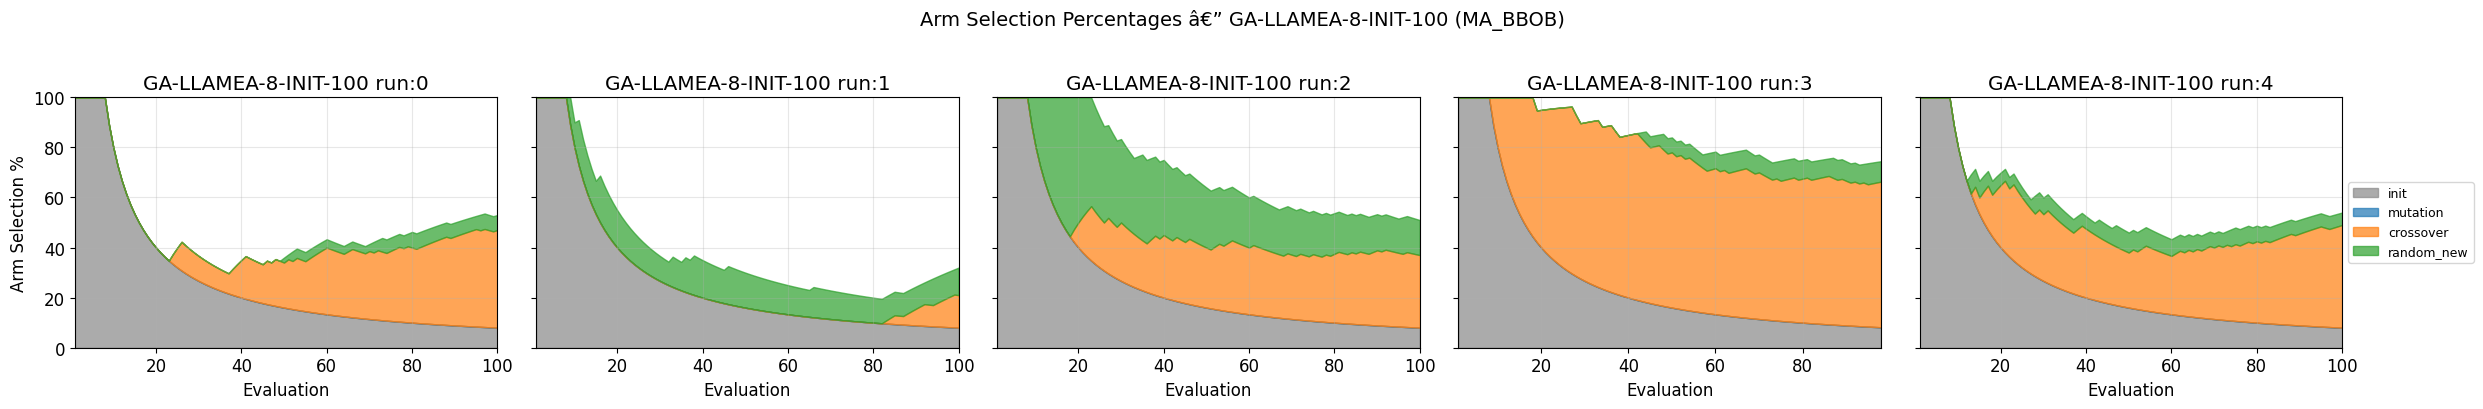

In [29]:
# Arm selection percentage over evaluations for GA-LLAMEA runs
try:
    ga_methods = [m for m in methods if 'GA-LLAMEA' in m.upper() or 'GA_LLAMEA' in m.upper()]
    if not ga_methods:
        print('No GA-LLAMEA methods found in the experiment.')
    else:
        for problem in problems:
            data = logger.get_problem_data(problem_name=problem)
            data.replace([-np.inf], 0, inplace=True)
            data.fillna(0, inplace=True)

            for ga_method in ga_methods:
                method_data = data[data['method_name'] == ga_method].copy()
                if method_data.empty:
                    print(f'No data for {ga_method}')
                    continue

                seeds = sorted(method_data['seed'].unique())
                num_seeds = len(seeds)

                fig, axes = plt.subplots(
                    1, num_seeds,
                    figsize=(5 * num_seeds, 4),
                    squeeze=False,
                    sharey=True,
                )

                operator_colors = {
                    'init': '#888888',
                    'mutation': '#1f77b4',
                    'crossover': '#ff7f0e',
                    'random_new': '#2ca02c',
                }
                operator_order = ['init', 'mutation', 'crossover', 'random_new']

                for seed_i, seed in enumerate(seeds):
                    ax = axes[0, seed_i]
                    run_data = method_data[method_data['seed'] == seed].copy().reset_index(drop=True)

                    # Extract operator from top-level field; fall back to metadata
                    operators = []
                    for _, row in run_data.iterrows():
                        op = row.get('operator', None)
                        if op is None or (isinstance(op, float) and np.isnan(op)):
                            meta = row.get('metadata', {})
                            if isinstance(meta, dict):
                                op = meta.get('operator', 'unknown')
                            else:
                                op = 'unknown'
                        operators.append(op)

                    # Compute cumulative percentages
                    eval_indices = list(range(1, len(operators) + 1))
                    cumulative = {op: [] for op in operator_order}
                    counts = {op: 0 for op in operator_order}

                    for i, op in enumerate(operators):
                        if op in counts:
                            counts[op] += 1
                        total = i + 1
                        for op_name in operator_order:
                            cumulative[op_name].append(counts[op_name] / total * 100)

                    # Stacked area plot
                    bottoms = np.zeros(len(eval_indices))
                    for op_name in operator_order:
                        values = np.array(cumulative[op_name])
                        ax.fill_between(
                            eval_indices, bottoms, bottoms + values,
                            alpha=0.7, label=op_name,
                            color=operator_colors.get(op_name, '#999999'),
                        )
                        bottoms += values

                    ax.set_xlim([1, len(operators)])
                    ax.set_ylim([0, 100])
                    ax.set_xlabel('Evaluation')
                    ax.set_title(f'{ga_method} run:{seed}')
                    if seed_i == 0:
                        ax.set_ylabel('Arm Selection %')
                    if seed_i == num_seeds - 1:
                        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

                fig.suptitle(f'Arm Selection Percentages â€” {ga_method} ({problem})', fontsize=14, y=1.02)
                plt.tight_layout()
                plt.show()

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f'Error plotting arm percentages: {e}')

## 5. Boxplots (Fitness Comparison)

Distribution of final fitness values found by each method.

Fitness Boxplot (grouped by method)


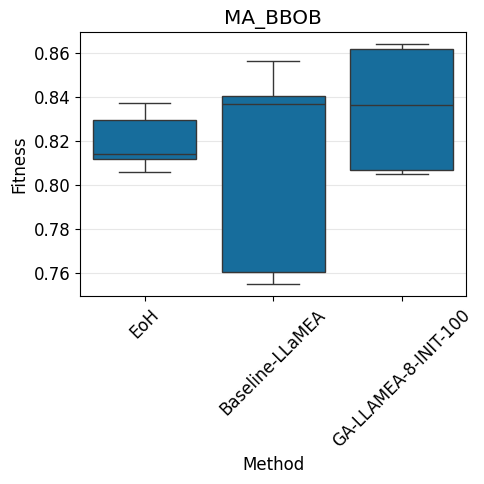

<Figure size 1200x800 with 0 Axes>

In [30]:
# Standard boxplot
print('Fitness Boxplot (grouped by method)')
try:
    plot_boxplot_fitness(logger)
    for ax in plt.gcf().get_axes():
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error plotting fitness boxplot: {e}')

Fitness Boxplot with Hue


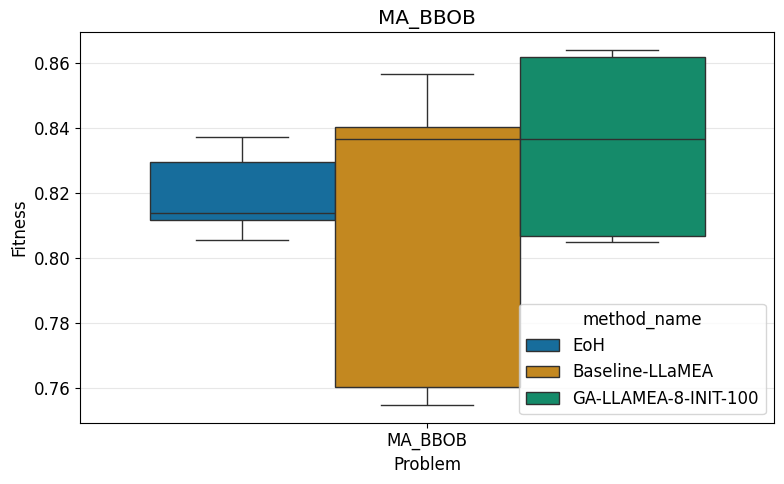

<Figure size 1200x800 with 0 Axes>

In [31]:
# Boxplot with hue distinction
print('Fitness Boxplot with Hue')
try:
    plot_boxplot_fitness_hue(logger)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error plotting fitness boxplot (hue): {e}')

## 6. Fitness Table (Statistical Summary)

Tabular summary of fitness statistics with mean, standard deviation, and p-values (Wilcoxon test).

In [32]:
print('Fitness Table (mean +/- std with p-values)')
try:
    table = fitness_table(logger)
    print(table)
except Exception as e:
    print(f'Error generating fitness table: {e}')

Fitness Table (mean +/- std with p-values)
                                    MA_BBOB
Baseline-LLaMEA       0.81 ± 0.04 (p=0.678)
EoH                   0.82 ± 0.01 (p=0.678)
GA-LLAMEA-8-INIT-100  0.83 ± 0.03 (p=0.354)


## 7. Behavior Metrics Analysis (Skipped)

Behavior metrics are skipped for this combined visualization.

In [33]:
print('Behavior metrics skipped for this visualization.')

Behavior metrics skipped for this visualization.


In [34]:
# Skipped

In [35]:
# Skipped

In [36]:
# Skipped

## 7. EAF / ECDF Diagrams

EAF (Empirical Attainment Function) and ECDF (Empirical Cumulative Distribution Function) diagrams require IOH-formatted benchmark data (`.dat` files from IOHprofiler).

IOH data is checked across all experiment directories.

In [37]:
# Check for IOH-formatted benchmark data across all experiment directories
ioh_data_dirs = []
for exp_dir in EXPERIMENT_DIRS:
    for subdir in ['ioh-data', 'ioh_data']:
        candidate = os.path.join(exp_dir, subdir)
        if os.path.isdir(candidate):
            ioh_data_dirs.append(candidate)

ioh_data_available = len(ioh_data_dirs) > 0

if ioh_data_available:
    print(f'IOH data found in {len(ioh_data_dirs)} location(s):')
    for d in ioh_data_dirs:
        print(f'  - {os.path.abspath(d)}')
else:
    print('No IOH-formatted benchmark data found.')
    print('Checked directories:')
    for exp_dir in EXPERIMENT_DIRS:
        for subdir in ['ioh-data', 'ioh_data']:
            candidate = os.path.join(exp_dir, subdir)
            print(f'  - {os.path.abspath(candidate)} (exists: {os.path.isdir(candidate)})')

IOH data found in 3 location(s):
  - c:\Users\Kukoy\Documents\Experiment-GA\WORKING-GA-LLAMEA\results\EoH\ioh-data
  - c:\Users\Kukoy\Documents\Experiment-GA\WORKING-GA-LLAMEA\results\CROSSOVER-ABLATION\baseline-LLAMEA\ioh-data
  - c:\Users\Kukoy\Documents\Experiment-GA\WORKING-GA-LLAMEA\results\GA-LLAMEA-8-INIT-100\ioh-data


IOH data loaded: 141428 rows
Algorithms: ['SHADE_DS_Archive', 'AdaptiveDifferentialEvolutionwithDynamicResurgenceThresholdandDiversifiedReSeeding', 'AdaptiveDifferentialEvolutionWithConvergentDualGuidance', 'DiversityEnhancedAdaptiveDifferentialEvolution', 'SuccessWeightedAdaptiveDE', 'AdaptiveSynergisticDifferentialEvolution', 'RoleBasedAdaptiveDifferentialEvolution', 'SaDE_DPA_GR', 'SynergisticEvolutionAdaptiveRejuvenationGuidedExploration', 'DifferentialEvolutionWithDynamicPBestPoolAndHybridRejuvenationArchive', 'JADEArchiveEvolution', 'AdaptiveStrategyEnsembleDE', 'AdaptiveDifferentialEvolutionWithDynamicPbestAndProgressiveStagnationEscape', 'AdaptiveDEWithArchiveAndRefinement', 'AdaptiveVectorBlendSearch']
Dimensions: [5]
Error generating EAF/ECDF: plot_ecdf() got an unexpected keyword argument 'y_max'


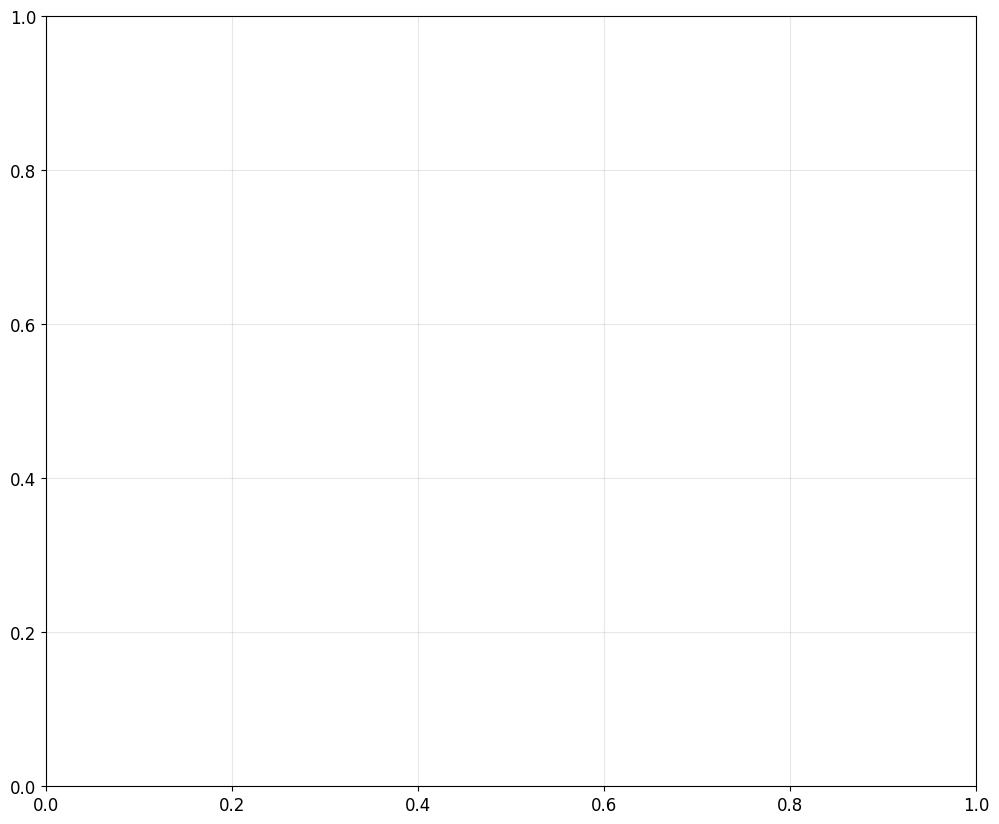

In [38]:
# If IOH data is available, generate ECDF and EAF plots
if ioh_data_available:
    try:
        import iohinspector
        import polars as pl

        manager = iohinspector.DataManager()
        for ioh_dir in ioh_data_dirs:
            manager.add_folder(ioh_dir)
        df_ioh = manager.load(monotonic=True, include_meta_data=True)

        print(f'IOH data loaded: {len(df_ioh)} rows')
        print(f'Algorithms: {df_ioh["algorithm_name"].unique().to_list()}')
        print(f'Dimensions: {df_ioh["dimension"].unique().to_list()}')

        # ECDF plot for dimension 5
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        _ = iohinspector.plot_ecdf(
            df_ioh.filter(pl.col('dimension') == 5),
            y_max=100, y_min=1e-8, ax=ax, scale_xlog=True
        )
        ax.set_title('ECDF â€” Combined Experiments (dim=5)')
        plt.tight_layout()
        plt.show()

        # EAF transformation and AOCC
        df_eaf = iohinspector.transform_fval(df_ioh, 1e-8, 1e2)
        aocc = iohinspector.get_aocc(
            df_eaf.filter(pl.col('dimension') == 5),
            10000,
            group_cols=['algorithm_name']
        )
        print('\nAOCC per algorithm (dim=5):')
        print(aocc)

    except ImportError:
        print('iohinspector not installed. Install with: pip install iohinspector')
    except Exception as e:
        print(f'Error generating EAF/ECDF: {e}')
else:
    print('Skipping EAF/ECDF â€” no IOH data available.')

## 8. Elo Rating (Tournament Ranking)

Elo ratings provide a tournament-based ranking of the algorithms evaluated using IOH benchmark data. The ranking is computed via `iohinspector.plot_tournament_ranking` over 100,000 rounds of simulated pairwise tournaments.

**Note:** This requires IOH-formatted data and the `iohinspector` package.

Error computing Elo ratings: module 'iohinspector' has no attribute 'plot'


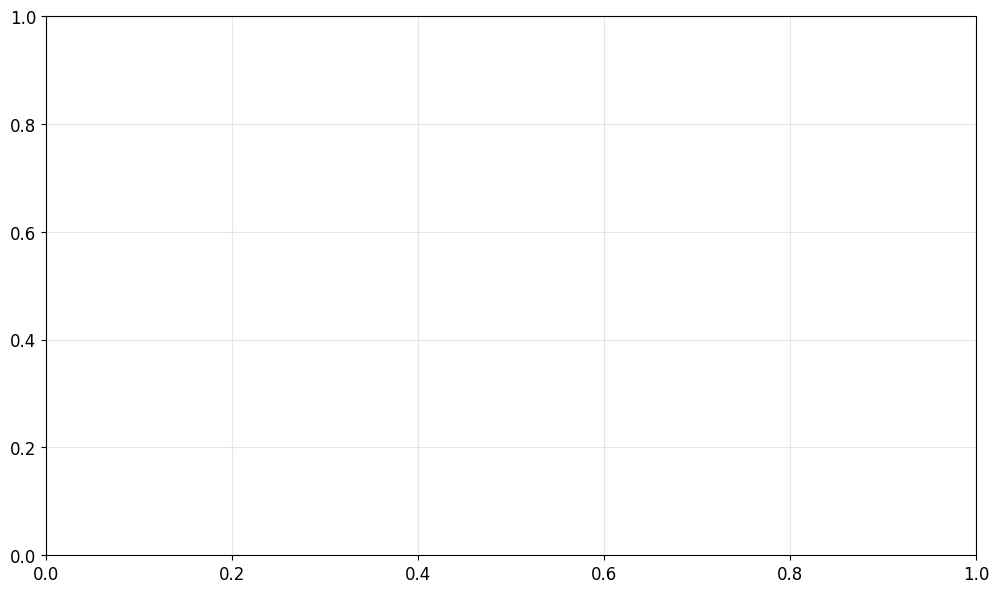

In [43]:
# Elo Rating (Tournament Ranking) - All algorithms (more fair / no best-per-method)
# Note: some `iohinspector` installs don't expose `iohinspector.plot`, so we
# compute the ratings table directly and then plot it ourselves.
if ioh_data_available:
    try:
        import iohinspector
        import polars as pl

        # Load IOH data if not already loaded
        if 'df_ioh' not in dir():
            manager = iohinspector.DataManager()
            for ioh_dir in ioh_data_dirs:
                manager.add_folder(ioh_dir)
            df_ioh = manager.load(monotonic=True, include_meta_data=True)

        # Compute Elo ratings directly
        dt_elo = iohinspector.get_tournament_ratings(df_ioh, nrounds=100000)
        dt_elo['Rating'] = pd.to_numeric(dt_elo['Rating'], errors='coerce')
        dt_elo['Deviation'] = pd.to_numeric(dt_elo['Deviation'], errors='coerce').fillna(0)

        dt_elo_sorted = dt_elo.sort_values(by='algorithm_name').reset_index(drop=True)

        _, ax = plt.subplots(1, 1, figsize=(10, 8))
        sns.pointplot(data=dt_elo_sorted, x='algorithm_name', y='Rating', linestyle='none', ax=ax)

        ax.errorbar(
            dt_elo_sorted['algorithm_name'],
            dt_elo_sorted['Rating'],
            yerr=dt_elo_sorted['Deviation'],
            fmt='o',
            color='blue',
            alpha=0.8,
            capsize=7,
            elinewidth=2.5,
        )
        ax.grid()

        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('')
        ax.set_title('Tournament Ranking (all algorithms)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print('\nElo Ratings (sorted by rating, best first):')
        print(dt_elo.sort_values(by='Rating', ascending=False).to_string(index=False))

    except ImportError as e:
        print(f'iohinspector or dependency not installed: {e}')
        print('Install with: pip install iohinspector')
    except Exception as e:
        print(f'Error computing Elo ratings: {e}')
else:
    print('Skipping Elo Rating - no IOH data available.')

## 9. Summary and Comparison

### Methods Overview

| Method | Source Experiment | Seeds | Type |
|--------|-------------------|-------|------|
| GA-LLAMEA-InitPrompt | COMPARISON-PROMPTS | 3 | GA-LLAMEA with init prompt variant |
| GA-LLAMEA-OriginalPrompt | COMPARISON-PROMPTS | 3 | GA-LLAMEA with original prompt |
| Baseline-LLaMEA | ABLATION-PROMPTS-CROSSOVER | 5 | Standard LLaMEA baseline |
| LLaMEA-Crossover1-NoRefine | ABLATION-PROMPTS-CROSSOVER | 5 | Single-parent crossover, no refinement |
| LLaMEA-Crossover3-NoRefine | ABLATION-PROMPTS-CROSSOVER | 5 | Three-parent crossover, no refinement |

### Observations

Refer to the convergence plots, boxplots, fitness table, EAF/ECDF diagrams, and Elo ratings above to draw conclusions about:

1. **Convergence Speed** â€” Which method converges fastest to high-quality solutions?
2. **Final Fitness** â€” Which method achieves the best final AOCC scores?
3. **Consistency** â€” Which method has the lowest variance across seeds?
4. **Prompt & Crossover Impact** â€” How do different prompt strategies and crossover variants compare?